# 04 : Fairness
**Owner:** Agit Sefkan Balcı

# Preprocessing

In this step, the project repository is cloned into Colab, the required Python packages are installed, and the project path is added so that the files inside `src` can be imported. Then, the OULAD CSV files are copied from Google Drive into the project `data` folder.

After the data files are ready, `prepare_artifacts.py` is executed. This script prepares the shared artifacts for all principle notebooks by loading the dataset, applying feature engineering, training the base model, and saving the model and test data files into the `data` folder. These saved files are later used in the fairness notebook for evaluation.

In [1]:
# ── Clone ────────────────────────────────────────────────
!git clone https://github.com/caltinuzengi/CS540-ethics-in-data-ai-project.git
%cd CS540-ethics-in-data-ai-project

# ── Dependencies ─────────────────────────────────────────
!pip install uv -q
!uv pip install --system -r requirements.txt

# ── Path ─────────────────────────────────────────────────
import sys
sys.path.append('/content/CS540-ethics-in-data-ai-project')

# ── Data (Google Drive) ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import shutil
from pathlib import Path

src = Path('/content/drive/MyDrive/OULAD')   # ← adjust to your Drive path
dst = Path('data')
dst.mkdir(exist_ok=True)
for f in src.glob('*.csv'):
    shutil.copy(f, dst / f.name)

print("Setup complete. Run notebooks in order: 01 → 02 → your module.")

Cloning into 'CS540-ethics-in-data-ai-project'...
remote: Enumerating objects: 99, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 99 (delta 49), reused 82 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (99/99), 1.06 MiB | 9.18 MiB/s, done.
Resolving deltas: 100% (49/49), done.
/content/CS540-ethics-in-data-ai-project
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 63.4 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 128 packages in 2.13s
Prepared 10 packages in 2.93s
Uninstalled 1 package in 73ms
Installed 10 packages in 217ms
 + async-lru==2.3.0
 + fairlearn==0.13.0
 + jedi==0.20.0
 + json5==0.14.0
 + jupyter==1.1.1
 + jupyter-lsp==2.3.1
 + jupyterlab==4.5.7
 + jupyterlab-server==2.28.0
 + lime==0.2.0.1
 - scipy==1.16.3
 + scipy==1.15.3
Mounted at /content/drive
Setup complete. Run notebooks in order: 01 → 02 → your module.


In [2]:
%cd /content/CS540-ethics-in-data-ai-project
!python prepare_artifacts.py

/content/CS540-ethics-in-data-ai-project
Preparing shared artifacts …
  Features: ['total_clicks', 'vle_days', 'weighted_score', 'submission_rate', 'num_of_prev_attempts', 'studied_credits', 'gender_enc', 'disability_enc', 'imd_band_enc', 'age_band_enc', 'highest_education_enc']
  Train size: 26074 | Test size: 6519
  Accuracy : 0.860
  F1-macro : 0.860
  ROC-AUC  : 0.941
✔ Artifacts saved → /content/CS540-ethics-in-data-ai-project/data


In [3]:
from pathlib import Path

data_dir = Path("/content/CS540-ethics-in-data-ai-project/data")

for name in ["base_model.pkl", "X_train.pkl", "X_test.pkl", "y_test.pkl"]:
    print(name, (data_dir / name).exists())

base_model.pkl True
X_train.pkl True
X_test.pkl True
y_test.pkl True


# Fairness Evaluation and Mitigation

This notebook evaluates whether the shared early warning model produces unequal outcomes across student groups. The main fairness focus is on gender, disability, socioeconomic background represented by IMD band, and age band.

The notebook first audits the baseline model. Then, it implements a fairness aware version by removing sensitive demographic attributes from direct model input while keeping them for fairness auditing.

In [4]:
from src.data_loader import load_oulad, encode_categoricals, get_feature_columns
from src.model import build_splits, train_model, evaluate_model

In [5]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("/content/CS540-ethics-in-data-ai-project")
DATA_DIR = PROJECT_ROOT / "data"

sys.path.append(str(PROJECT_ROOT))

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

model = joblib.load(DATA_DIR / "base_model.pkl")
X_train = joblib.load(DATA_DIR / "X_train.pkl")
X_test = joblib.load(DATA_DIR / "X_test.pkl")
y_test = joblib.load(DATA_DIR / "y_test.pkl")

print("Artifacts loaded successfully.")
print("Model:", type(model))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("\nFeature columns:")
print(list(X_test.columns))
print("\nTarget labels:")
print(sorted(y_test.unique()))

Artifacts loaded successfully.
Model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
X_train shape: (26074, 11)
X_test shape: (6519, 11)
y_test shape: (6519,)

Feature columns:
['total_clicks', 'vle_days', 'weighted_score', 'submission_rate', 'num_of_prev_attempts', 'studied_credits', 'gender_enc', 'disability_enc', 'imd_band_enc', 'age_band_enc', 'highest_education_enc']

Target labels:
[np.int64(0), np.int64(1)]


## Risk Label Definition

The original model predicts the final student outcome. For fairness evaluation, this is converted into a binary early warning task. Students with `Fail` or `Withdrawn` outcomes are treated as at risk. Students with `Pass` or `Distinction` outcomes are treated as not at risk.

This framing is suitable for an early warning system because the ethical concern is whether some groups are more likely to be flagged, missed, or wrongly classified by the system.

In [6]:
# The prepared base model already uses a binary target:
# 0 = Not at risk
# 1 = At risk

y_pred = model.predict(X_test)

y_true_risk = pd.Series(y_test, index=X_test.index).astype(int)
y_pred_risk = pd.Series(y_pred, index=X_test.index).astype(int)

print("Unique values in y_test:", sorted(y_true_risk.unique()))
print("Unique values in predictions:", sorted(y_pred_risk.unique()))

print("\nBinary risk classification report:")
print(classification_report(
    y_true_risk,
    y_pred_risk,
    labels=[0, 1],
    target_names=["Not at risk", "At risk"],
    zero_division=0
))

Unique values in y_test: [np.int64(0), np.int64(1)]
Unique values in predictions: [np.int64(0), np.int64(1)]

Binary risk classification report:
              precision    recall  f1-score   support

 Not at risk       0.82      0.89      0.86      3077
     At risk       0.90      0.83      0.86      3442

    accuracy                           0.86      6519
   macro avg       0.86      0.86      0.86      6519
weighted avg       0.86      0.86      0.86      6519



In [7]:
fairness_df = X_test.copy()

fairness_df["y_true_risk"] = y_true_risk
fairness_df["y_pred_risk"] = y_pred_risk

fairness_df.head()

,total_clicks,vle_days,weighted_score,submission_rate,num_of_prev_attempts,studied_credits,gender_enc,disability_enc,imd_band_enc,age_band_enc,highest_education_enc,y_true_risk,y_pred_risk
23252,2948.0,95.0,80.750000,1.0,0,60,1,0,-1,1,2,0,0
30849,39.0,7.0,0.000000,0.0,0,30,1,0,1,1,2,1,1
21169,388.0,29.0,56.920000,1.0,1,90,0,0,7,0,0,0,1
30521,940.0,58.0,81.111111,1.0,0,30,0,0,4,1,2,0,0
29539,2866.0,85.0,71.250000,1.0,0,120,1,0,2,0,0,0,0


In [8]:
sensitive_columns = [
    "gender_enc",
    "disability_enc",
    "imd_band_enc",
    "age_band_enc"
]

for col in sensitive_columns:
    print(col, "exists:", col in fairness_df.columns)

gender_enc exists: True
disability_enc exists: True
imd_band_enc exists: True
age_band_enc exists: True


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import numpy as np
import pandas as pd

def group_fairness_metrics(df, group_col):
    rows = []

    for group_value, group_df in df.groupby(group_col):
        y_true_group = group_df["y_true_risk"]
        y_pred_group = group_df["y_pred_risk"]

        tn, fp, fn, tp = confusion_matrix(
            y_true_group,
            y_pred_group,
            labels=[0, 1]
        ).ravel()

        rows.append({
            "group": group_value,
            "n": len(group_df),
            "accuracy": accuracy_score(y_true_group, y_pred_group),
            "selection_rate": y_pred_group.mean(),
            "true_positive_rate": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
            "false_positive_rate": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "false_negative_rate": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "precision": precision_score(y_true_group, y_pred_group, zero_division=0),
            "recall": recall_score(y_true_group, y_pred_group, zero_division=0)
        })

    return pd.DataFrame(rows)


def disparity_summary(metrics_df):
    selected_metrics = [
        "selection_rate",
        "true_positive_rate",
        "false_positive_rate",
        "false_negative_rate",
        "accuracy"
    ]

    rows = []

    for metric in selected_metrics:
        max_value = metrics_df[metric].max()
        min_value = metrics_df[metric].min()

        rows.append({
            "metric": metric,
            "min": min_value,
            "max": max_value,
            "absolute_difference": max_value - min_value,
            "min_to_max_ratio": min_value / max_value if max_value > 0 else np.nan
        })

    return pd.DataFrame(rows)

In [10]:
baseline_group_results = {}
baseline_disparity_results = {}

for group_col in sensitive_columns:
    metrics = group_fairness_metrics(fairness_df, group_col)
    disparity = disparity_summary(metrics)

    baseline_group_results[group_col] = metrics
    baseline_disparity_results[group_col] = disparity

    print(f"\nBaseline fairness metrics by {group_col}")
    display(metrics)

    print(f"\nBaseline disparity summary for {group_col}")
    display(disparity)


Baseline fairness metrics by gender_enc


,group,n,accuracy,selection_rate,true_positive_rate,false_positive_rate,false_negative_rate,precision,recall
0,0,2917,0.846075,0.477545,0.814248,0.120141,0.185752,0.877961,0.814248
1,1,3602,0.871738,0.495836,0.841237,0.092659,0.158763,0.913774,0.841237



Baseline disparity summary for gender_enc


,metric,min,max,absolute_difference,min_to_max_ratio
0,selection_rate,0.477545,0.495836,0.018290,0.963112
1,true_positive_rate,0.814248,0.841237,0.026989,0.967917
2,false_positive_rate,0.092659,0.120141,0.027482,0.771254
3,false_negative_rate,0.158763,0.185752,0.026989,0.854702
4,accuracy,0.846075,0.871738,0.025663,0.970561



Baseline fairness metrics by disability_enc


...

,metric,min,max,absolute_difference,min_to_max_ratio
0,selection_rate,0.291667,0.627907,0.336240,0.464506
1,true_positive_rate,0.732394,0.887019,0.154625,0.825680
2,false_positive_rate,0.060498,0.189781,0.129283,0.318779
3,false_negative_rate,0.112981,0.267606,0.154625,0.422191
4,accuracy,0.825648,0.897482,0.071834,0.919961



Baseline fairness metrics by age_band_enc


,group,n,accuracy,selection_rate,true_positive_rate,false_positive_rate,false_negative_rate,precision,recall
0,0,4612,0.859063,0.519081,0.837461,0.113412,0.162539,0.903926,0.837461
1,1,1854,0.863538,0.413700,0.806683,0.089567,0.193317,0.881356,0.806683
2,2,53,0.849057,0.339623,0.750000,0.090909,0.250000,0.833333,0.750000



Baseline disparity summary for age_band_enc


,metric,min,max,absolute_difference,min_to_max_ratio
0,selection_rate,0.339623,0.519081,0.179458,0.654277
1,true_positive_rate,0.750000,0.837461,0.087461,0.895564
2,false_positive_rate,0.089567,0.113412,0.023845,0.789747
3,false_negative_rate,0.162539,0.250000,0.087461,0.650155
4,accuracy,0.849057,0.863538,0.014482,0.983230


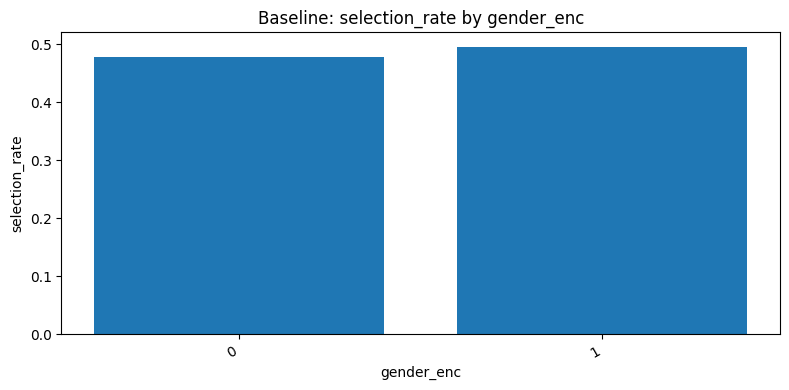

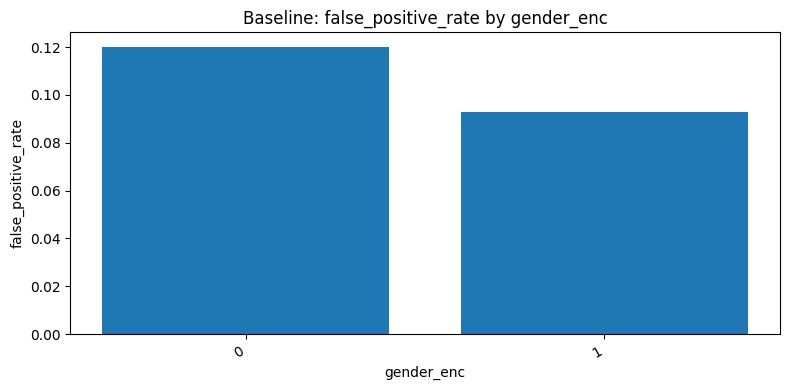

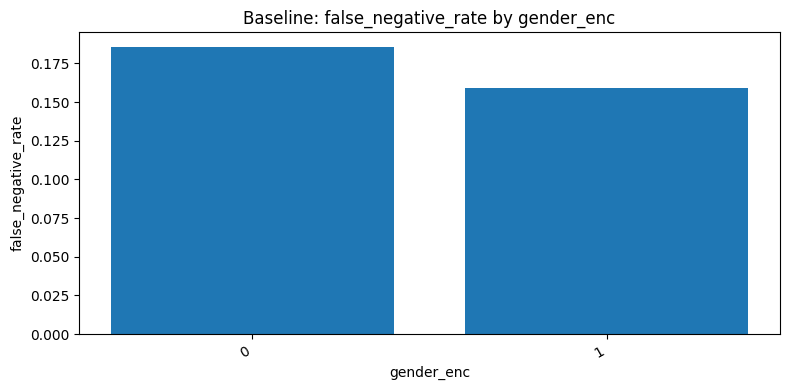

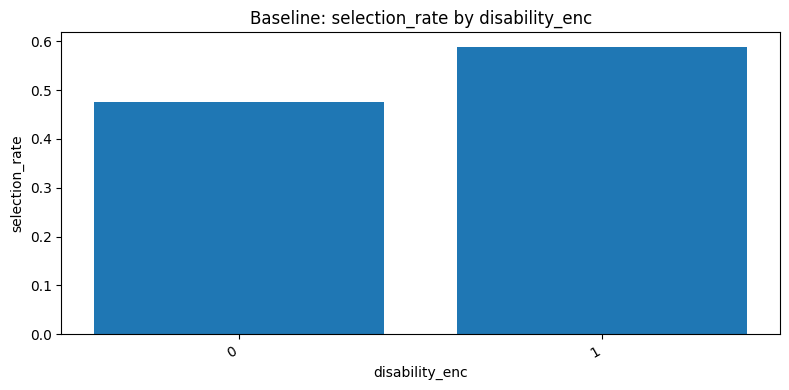

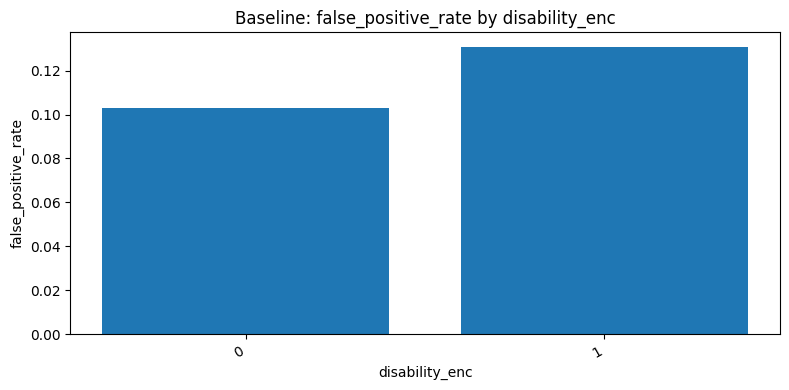

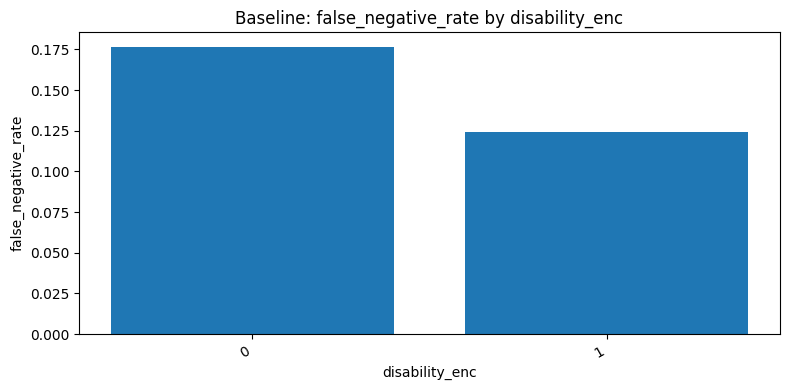

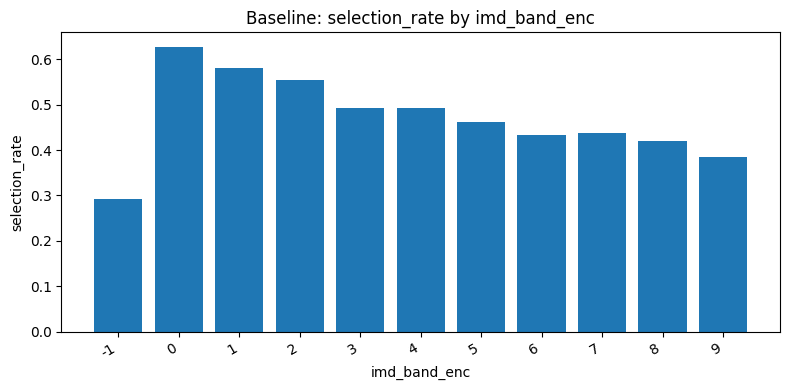

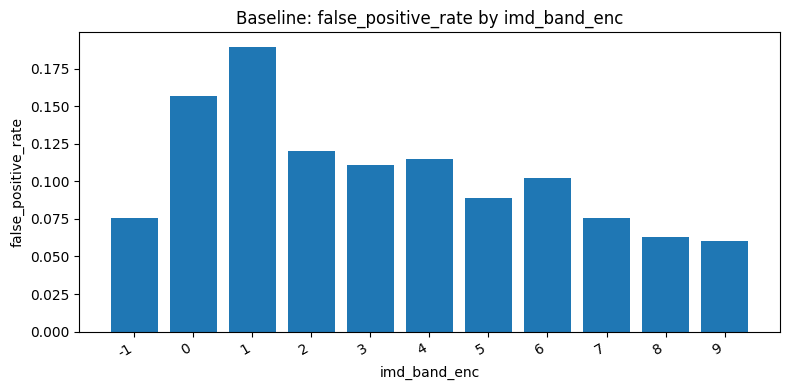

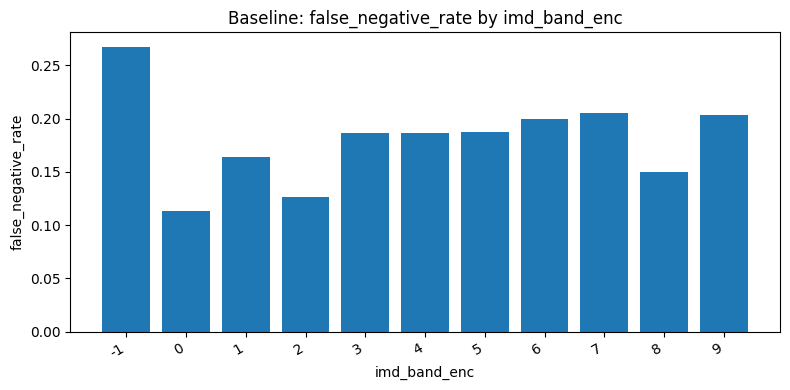

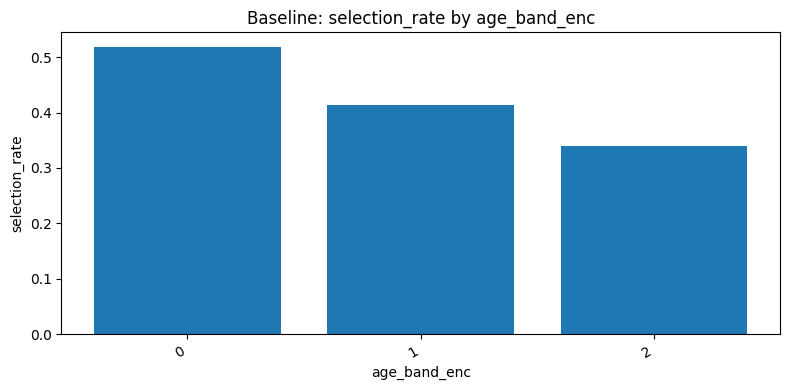

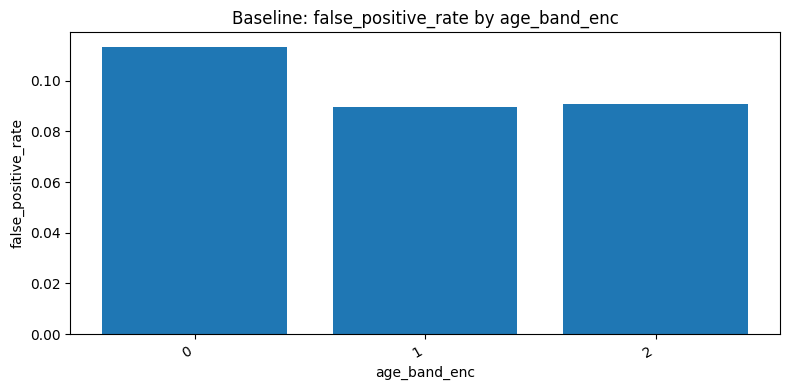

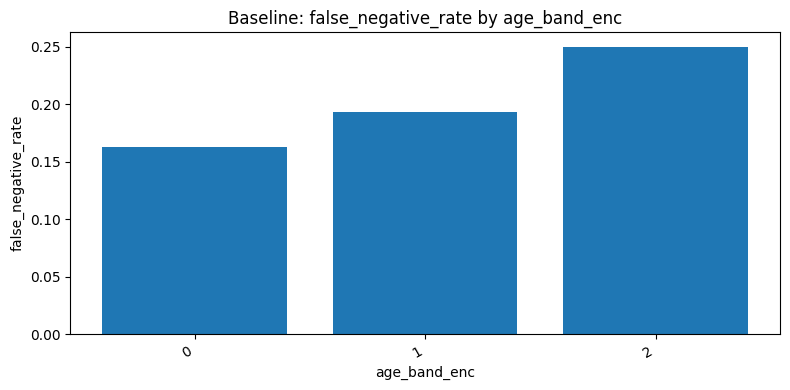

In [11]:
import matplotlib.pyplot as plt

def plot_group_metric(metrics_df, group_col, metric, title_prefix="Baseline"):
    plt.figure(figsize=(8, 4))
    plt.bar(metrics_df["group"].astype(str), metrics_df[metric])
    plt.title(f"{title_prefix}: {metric} by {group_col}")
    plt.xlabel(group_col)
    plt.ylabel(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


for group_col in sensitive_columns:
    metrics = baseline_group_results[group_col]

    plot_group_metric(metrics, group_col, "selection_rate")
    plot_group_metric(metrics, group_col, "false_positive_rate")
    plot_group_metric(metrics, group_col, "false_negative_rate")

In [12]:
print("y_train.pkl exists:", (DATA_DIR / "y_train.pkl").exists())


y_train.pkl exists: False


# Fairness Aware Mitigation

The baseline audit shows whether the shared model produces unequal outcomes across student groups. As a mitigation step, this notebook trains a second model that removes selected sensitive demographic attributes from direct model input.

Importantly, the sensitive attributes are not deleted from the fairness process. They are still kept for the audit layer, because fairness cannot be checked without group information. This creates a separation between prediction and accountability.

In [13]:
from src.data_loader import load_oulad, encode_categoricals, get_feature_columns
from src.model import build_splits, train_model

# Recreate the same prepared dataset used by prepare_artifacts.py
df = load_oulad(DATA_DIR)
df = encode_categoricals(df)

# get_feature_columns returns:
# 1. base numerical feature columns
# 2. sensitive categorical columns
base_feature_cols, sensitive_original_cols = get_feature_columns(df)

encoded_sensitive_cols = [
    col + "_enc"
    for col in sensitive_original_cols
    if col + "_enc" in df.columns
]

feature_cols = base_feature_cols + encoded_sensitive_cols

print("Base feature columns:")
print(base_feature_cols)

print("\nSensitive original columns:")
print(sensitive_original_cols)

print("\nEncoded sensitive columns used:")
print(encoded_sensitive_cols)

print("\nFinal feature columns:")
print(feature_cols)

print("\nTarget distribution:")
print(df["target"].value_counts())

X_train_full, X_test_full, y_train_full, y_test_full = build_splits(
    df,
    feature_cols,
    target_col="target"
)

print("\nRecreated train and test data")
print("X_train_full:", X_train_full.shape)
print("X_test_full:", X_test_full.shape)
print("y_train_full:", y_train_full.shape)
print("y_test_full:", y_test_full.shape)

Base feature columns:
['total_clicks', 'vle_days', 'weighted_score', 'submission_rate', 'num_of_prev_attempts', 'studied_credits']

Sensitive original columns:
['gender', 'disability', 'imd_band', 'age_band', 'highest_education']

Encoded sensitive columns used:
['gender_enc', 'disability_enc', 'imd_band_enc', 'age_band_enc', 'highest_education_enc']

Final feature columns:
['total_clicks', 'vle_days', 'weighted_score', 'submission_rate', 'num_of_prev_attempts', 'studied_credits', 'gender_enc', 'disability_enc', 'imd_band_enc', 'age_band_enc', 'highest_education_enc']

Target distribution:
target
1    17208
0    15385
Name: count, dtype: int64

Recreated train and test data
X_train_full: (26074, 11)
X_test_full: (6519, 11)
y_train_full: (26074,)
y_test_full: (6519,)


In [14]:
import inspect
from src.model import build_splits

print(inspect.signature(build_splits))

(df: pandas.core.frame.DataFrame, feature_cols: list[str], target_col: str = 'target', test_size: float = 0.2, random_state: int = 42)


In [15]:
sensitive_direct_inputs = [
    "gender_enc",
    "disability_enc",
    "imd_band_enc",
    "age_band_enc"
]

columns_to_drop = [
    col for col in sensitive_direct_inputs
    if col in X_train_full.columns
]

print("Columns removed from direct model input:")
print(columns_to_drop)

X_train_mitigated = X_train_full.drop(columns=columns_to_drop)
X_test_mitigated = X_test_full.drop(columns=columns_to_drop)

mitigated_model = train_model(X_train_mitigated, y_train_full)

mitigated_y_pred = mitigated_model.predict(X_test_mitigated)

mitigated_y_true_risk = pd.Series(y_test_full, index=X_test_full.index).astype(int)
mitigated_y_pred_risk = pd.Series(mitigated_y_pred, index=X_test_full.index).astype(int)

print("Mitigated model risk classification report:")
print(classification_report(
    mitigated_y_true_risk,
    mitigated_y_pred_risk,
    labels=[0, 1],
    target_names=["Not at risk", "At risk"],
    zero_division=0
))

Columns removed from direct model input:
['gender_enc', 'disability_enc', 'imd_band_enc', 'age_band_enc']
Mitigated model risk classification report:
              precision    recall  f1-score   support

 Not at risk       0.82      0.89      0.85      3077
     At risk       0.89      0.83      0.86      3442

    accuracy                           0.86      6519
   macro avg       0.86      0.86      0.86      6519
weighted avg       0.86      0.86      0.86      6519



In [16]:
mitigated_fairness_df = X_test_full.copy()

mitigated_fairness_df["y_true_risk"] = mitigated_y_true_risk
mitigated_fairness_df["y_pred_risk"] = mitigated_y_pred_risk

mitigated_fairness_df.head()

,total_clicks,vle_days,weighted_score,submission_rate,num_of_prev_attempts,studied_credits,gender_enc,disability_enc,imd_band_enc,age_band_enc,highest_education_enc,y_true_risk,y_pred_risk
23252,2948.0,95.0,80.750000,1.0,0,60,1,0,-1,1,2,0,0
30849,39.0,7.0,0.000000,0.0,0,30,1,0,1,1,2,1,1
21169,388.0,29.0,56.920000,1.0,1,90,0,0,7,0,0,0,1
30521,940.0,58.0,81.111111,1.0,0,30,0,0,4,1,2,0,0
29539,2866.0,85.0,71.250000,1.0,0,120,1,0,2,0,0,0,0


In [17]:
mitigated_group_results = {}
mitigated_disparity_results = {}

for group_col in sensitive_columns:
    metrics = group_fairness_metrics(mitigated_fairness_df, group_col)
    disparity = disparity_summary(metrics)

    mitigated_group_results[group_col] = metrics
    mitigated_disparity_results[group_col] = disparity

    print(f"\nMitigated fairness metrics by {group_col}")
    display(metrics)

    print(f"\nMitigated disparity summary for {group_col}")
    display(disparity)


Mitigated fairness metrics by gender_enc


,group,n,accuracy,selection_rate,true_positive_rate,false_positive_rate,false_negative_rate,precision,recall
0,0,2917,0.842647,0.515941,0.848202,0.163251,0.151798,0.846512,0.848202
1,1,3602,0.868129,0.474459,0.818041,0.073406,0.181959,0.928613,0.818041



Mitigated disparity summary for gender_enc


,metric,min,max,absolute_difference,min_to_max_ratio
0,selection_rate,0.474459,0.515941,0.041482,0.919599
1,true_positive_rate,0.818041,0.848202,0.030161,0.964441
2,false_positive_rate,0.073406,0.163251,0.089845,0.449649
3,false_negative_rate,0.151798,0.181959,0.030161,0.834242
4,accuracy,0.842647,0.868129,0.025482,0.970647



Mitigated fairness metrics by disability_enc


...

,metric,min,max,absolute_difference,min_to_max_ratio
0,selection_rate,0.273148,0.607752,0.334604,0.449440
1,true_positive_rate,0.718310,0.869565,0.151255,0.826056
2,false_positive_rate,0.055172,0.182482,0.127309,0.302345
3,false_negative_rate,0.130435,0.281690,0.151255,0.463043
4,accuracy,0.822767,0.890288,0.067521,0.924158



Mitigated fairness metrics by age_band_enc


,group,n,accuracy,selection_rate,true_positive_rate,false_positive_rate,false_negative_rate,precision,recall
0,0,4612,0.856678,0.522767,0.838622,0.120316,0.161378,0.898797,0.838622
1,1,1854,0.855987,0.424488,0.810263,0.106299,0.189737,0.862770,0.810263
2,2,53,0.886792,0.301887,0.750000,0.030303,0.250000,0.937500,0.750000



Mitigated disparity summary for age_band_enc


,metric,min,max,absolute_difference,min_to_max_ratio
0,selection_rate,0.301887,0.522767,0.220880,0.577479
1,true_positive_rate,0.750000,0.838622,0.088622,0.894324
2,false_positive_rate,0.030303,0.120316,0.090013,0.251863
3,false_negative_rate,0.161378,0.250000,0.088622,0.645511
4,accuracy,0.855987,0.886792,0.030805,0.965262


# Baseline vs Mitigated Model Interpretation

The mitigation results do not show a uniform fairness improvement. Removing selected sensitive attributes from the direct prediction input reduced some disparities, but increased others. For example, the disparity in selection rate and false negative rate slightly decreased for IMD band, but gender and age related false positive disparities increased.

This shows that sensitive attribute removal is not sufficient as a standalone fairness solution. Even when demographic attributes are removed from direct model input, other features may still act as proxies for structural disadvantage. Therefore, the proposed fairness design should not be presented as a fully corrected model. Instead, it should be presented as a mixed fairness framework that combines partial mitigation with continuous auditing.

The main ethical contribution is the audit layer. It makes unequal error patterns visible across student groups and can support human review before the system is used for educational intervention decisions.

In [18]:
comparison_rows = []

for group_col in sensitive_columns:
    baseline_disp = baseline_disparity_results[group_col]
    mitigated_disp = mitigated_disparity_results[group_col]

    for metric in baseline_disp["metric"]:
        baseline_value = baseline_disp.loc[
            baseline_disp["metric"] == metric,
            "absolute_difference"
        ].values[0]

        mitigated_value = mitigated_disp.loc[
            mitigated_disp["metric"] == metric,
            "absolute_difference"
        ].values[0]

        comparison_rows.append({
            "group_column": group_col,
            "metric": metric,
            "baseline_difference": baseline_value,
            "mitigated_difference": mitigated_value,
            "change": mitigated_value - baseline_value
        })

comparison_df = pd.DataFrame(comparison_rows)

display(comparison_df)

,group_column,metric,baseline_difference,mitigated_difference,change
0,gender_enc,selection_rate,0.018290,0.041482,0.023192
1,gender_enc,true_positive_rate,0.026989,0.030161,0.003172
2,gender_enc,false_positive_rate,0.027482,0.089845,0.062363
3,gender_enc,false_negative_rate,0.026989,0.030161,0.003172
4,gender_enc,accuracy,0.025663,0.025482,-0.000181
5,disability_enc,selection_rate,0.113017,0.103654,-0.009363
6,disability_enc,true_positive_rate,0.052633,0.033796,-0.018837
7,disability_enc,false_positive_rate,0.027944,0.034967,0.007023
8,disability_enc,false_negative_rate,0.052633,0.033796,-0.018837
9,disability_enc,accuracy,0.014483,0.001433,-0.013050


In [19]:
comparison_df["interpretation"] = comparison_df["change"].apply(
    lambda x: "decreased disparity" if x < 0
    else "increased disparity" if x > 0
    else "no change"
)

display(comparison_df)

,group_column,metric,baseline_difference,mitigated_difference,change,interpretation
0,gender_enc,selection_rate,0.018290,0.041482,0.023192,increased disparity
1,gender_enc,true_positive_rate,0.026989,0.030161,0.003172,increased disparity
2,gender_enc,false_positive_rate,0.027482,0.089845,0.062363,increased disparity
3,gender_enc,false_negative_rate,0.026989,0.030161,0.003172,increased disparity
4,gender_enc,accuracy,0.025663,0.025482,-0.000181,decreased disparity
5,disability_enc,selection_rate,0.113017,0.103654,-0.009363,decreased disparity
6,disability_enc,true_positive_rate,0.052633,0.033796,-0.018837,decreased disparity
7,disability_enc,false_positive_rate,0.027944,0.034967,0.007023,increased disparity
8,disability_enc,false_negative_rate,0.052633,0.033796,-0.018837,decreased disparity
9,disability_enc,accuracy,0.014483,0.001433,-0.013050,decreased disparity


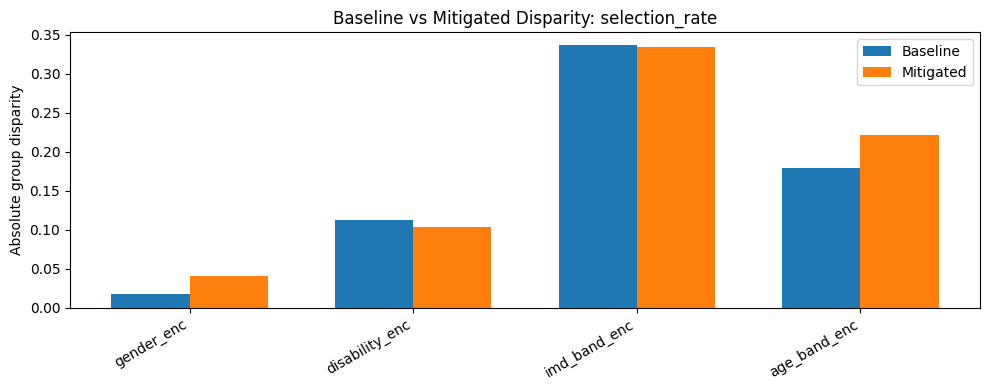

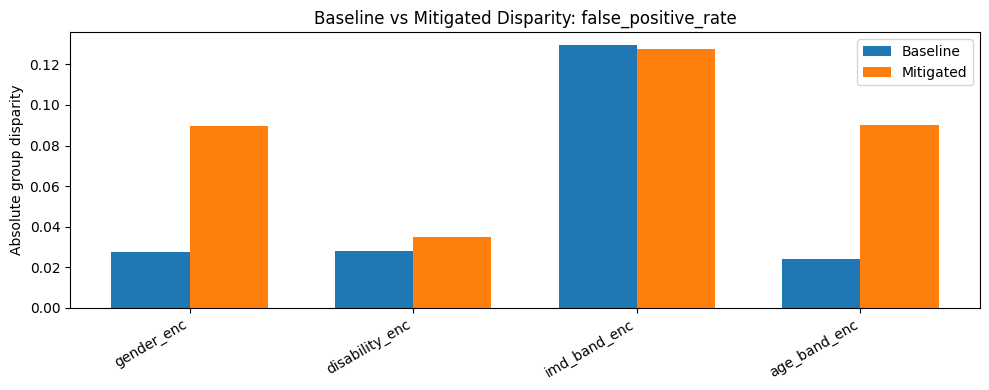

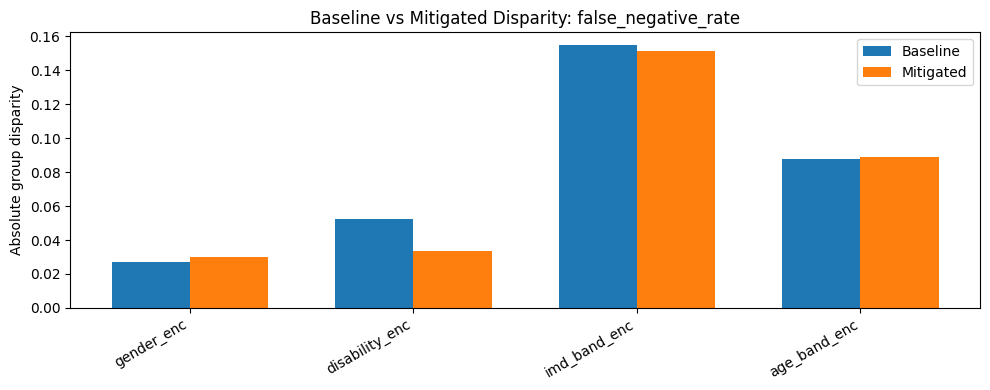

In [20]:
def plot_baseline_vs_mitigated(comparison_df, metric_name):
    subset = comparison_df[comparison_df["metric"] == metric_name]

    x = np.arange(len(subset))
    width = 0.35

    plt.figure(figsize=(10, 4))
    plt.bar(x - width / 2, subset["baseline_difference"], width, label="Baseline")
    plt.bar(x + width / 2, subset["mitigated_difference"], width, label="Mitigated")

    plt.xticks(x, subset["group_column"], rotation=30, ha="right")
    plt.ylabel("Absolute group disparity")
    plt.title(f"Baseline vs Mitigated Disparity: {metric_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_baseline_vs_mitigated(comparison_df, "selection_rate")
plot_baseline_vs_mitigated(comparison_df, "false_positive_rate")
plot_baseline_vs_mitigated(comparison_df, "false_negative_rate")

In [21]:
improvement_summary = comparison_df.copy()

improvement_summary["direction"] = improvement_summary["change"].apply(
    lambda x: "improved" if x < 0
    else "worsened" if x > 0
    else "unchanged"
)

display(improvement_summary)

print("Overall counts:")
print(improvement_summary["direction"].value_counts())

,group_column,metric,baseline_difference,mitigated_difference,change,interpretation,direction
0,gender_enc,selection_rate,0.018290,0.041482,0.023192,increased disparity,worsened
1,gender_enc,true_positive_rate,0.026989,0.030161,0.003172,increased disparity,worsened
2,gender_enc,false_positive_rate,0.027482,0.089845,0.062363,increased disparity,worsened
3,gender_enc,false_negative_rate,0.026989,0.030161,0.003172,increased disparity,worsened
4,gender_enc,accuracy,0.025663,0.025482,-0.000181,decreased disparity,improved
5,disability_enc,selection_rate,0.113017,0.103654,-0.009363,decreased disparity,improved
6,disability_enc,true_positive_rate,0.052633,0.033796,-0.018837,decreased disparity,improved
7,disability_enc,false_positive_rate,0.027944,0.034967,0.007023,increased disparity,worsened
8,disability_enc,false_negative_rate,0.052633,0.033796,-0.018837,decreased disparity,improved
9,disability_enc,accuracy,0.014483,0.001433,-0.013050,decreased disparity,improved


Overall counts:
direction
worsened    10
improved    10
Name: count, dtype: int64


# Additional Fairlearn Based Fairness Check

As an additional check, this notebook also uses the `src/fairness.py` module. This module reports group level fairness metrics with Fairlearn, including demographic parity difference and equalized odds difference. This section is not used as the main mitigation method, but it provides a standardized fairness audit that supports the manual analysis above.

In [22]:
from src.fairness import compute_fairness_report, print_fairness_summary

selected_fairlearn_groups = [
    "gender_enc",
    "disability_enc",
    "imd_band_enc",
    "age_band_enc"
]

for group_col in selected_fairlearn_groups:
    print(f"\n\nFairlearn baseline fairness summary for {group_col}")

    mf = compute_fairness_report(
        y_true=y_true_risk,
        y_pred=y_pred_risk,
        sensitive_features=fairness_df[group_col]
    )

    print_fairness_summary(
        mf,
        y_true_risk,
        y_pred_risk,
        fairness_df[group_col]
    )



Fairlearn baseline fairness summary for gender_enc
=== Overall Metrics ===
accuracy          0.860255
selection_rate    0.487651
f1                0.862407
dtype: float64

=== Per-Group Metrics ===
            accuracy  selection_rate        f1
gender_enc                                    
0           0.846075        0.477545  0.844905
1           0.871738        0.495836  0.876006

Demographic Parity Difference: 0.0183  (0 = perfectly fair)
Equalized Odds Difference:     0.0275  (0 = perfectly fair)


Fairlearn baseline fairness summary for disability_enc
=== Overall Metrics ===
accuracy          0.860255
selection_rate    0.487651
f1                0.862407
dtype: float64

=== Per-Group Metrics ===
                accuracy  selection_rate        f1
disability_enc                                    
0               0.858799        0.476296  0.858025
1               0.873282        0.589313  0.894804

Demographic Parity Difference: 0.1130  (0 = perfectly fair)
Equalized Odds Differe

In [23]:
for group_col in selected_fairlearn_groups:
    print(f"\n\nFairlearn feature removal fairness summary for {group_col}")

    mf = compute_fairness_report(
        y_true=mitigated_y_true_risk,
        y_pred=mitigated_y_pred_risk,
        sensitive_features=mitigated_fairness_df[group_col]
    )

    print_fairness_summary(
        mf,
        mitigated_y_true_risk,
        mitigated_y_pred_risk,
        mitigated_fairness_df[group_col]
    )



Fairlearn feature removal fairness summary for gender_enc
=== Overall Metrics ===
accuracy          0.856726
selection_rate    0.493020
f1                0.859675
dtype: float64

=== Per-Group Metrics ===
            accuracy  selection_rate        f1
gender_enc                                    
0           0.842647        0.515941  0.847356
1           0.868129        0.474459  0.869827

Demographic Parity Difference: 0.0415  (0 = perfectly fair)
Equalized Odds Difference:     0.0898  (0 = perfectly fair)


Fairlearn feature removal fairness summary for disability_enc
=== Overall Metrics ===
accuracy          0.856726
selection_rate    0.493020
f1                0.859675
dtype: float64

=== Per-Group Metrics ===
                accuracy  selection_rate        f1
disability_enc                                    
0               0.856583        0.482606  0.856705
1               0.858015        0.586260  0.881830

Demographic Parity Difference: 0.1037  (0 = perfectly fair)
Equalize